# Analisis Dampak Penggunaan AI Generatif terhadap Performa Akademik dan Kesejahteraan Mahasiswa


## Persiapan Analisis
Mengimpor pustaka untuk manipulasi data, statistik, dan visualisasi, serta mengatur visualisasi grafik agar konsisten (sederhana, kontras, tanpa grid, dan menggunakan label Bahasa Indonesia).

In [134]:
# Mengimpor pustaka utama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os

# Mengabaikan peringatan agar tampilan laporan tetap rapi
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
sns.set_theme(style='white') # Mengatur latar belakang putih polos
plt.rcParams['font.sans-serif'] = 'Times New Roman' # Font standar profesional
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.grid'] = False # Memastikan tidak ada garis kisi (grid) sesuai instruksi
plt.rcParams['grid.alpha'] = 0.0 # Grid transparansi 0
plt.rcParams['axes.spines.top'] = False # Menghilangkan garis bingkai atas
plt.rcParams['axes.spines.right'] = False # Menghilangkan garis bingkai kanan


# Identifikasi Kebutuhan Pengelolaan Data untuk Proses Bisnis

Merumuskan 7 pertanyaan bisnis analitik terukur, menentukan pemangku kepentingan, dan menetapkan batasan serta asumsi proyek. Perumusan mengacu pada Framework SMART dan Key Business Question Framework agar setiap pertanyaan spesifik, terukur, relevan, dan berorientasi pada tindakan.

### 7 Pertanyaan Bisnis Analitik Terukur

| Kode | Tema | Pertanyaan Bisnis | Variabel Utama | Metode Analisis |
| :--- | :--- | :--- | :--- | :--- |
| **PB-01** | Dampak Akademik | Apakah mahasiswa yang menggunakan AI generatif secara intensif menunjukkan peningkatan prestasi akademik yang lebih signifikan di akhir semester, dan seberapa besar selisih peningkatannya? | `Pre_Semester_GPA`, `Post_Semester_GPA`, `AI_Usage_Segment` | Segmentasi (Light/Moderate/Heavy) + ANOVA/T-Test |
| **PB-02** | Retensi Pengetahuan | Sejauh mana tingkat ketergantungan mahasiswa terhadap AI berdampak negatif terhadap kemampuan mempertahankan materi secara mandiri pasca-semester, dan apakah ada ambang batas yang perlu diwaspadai? | `Perceived_AI_Dependency`, `Skill_Retention_Score`, `Traditional_Study_Hours` | Korelasi Pearson/Spearman + Regresi Linier |
| **PB-03** | Kombinasi Belajar Optimal | Bagaimana kombinasi optimal antara jam belajar mandiri dan jam pemanfaatan AI per minggu yang menghasilkan performa akademik tertinggi, dan apakah berbeda antar bidang studi? | `Traditional_Study_Hours`, `Weekly_GenAI_Hours`, `Post_Semester_GPA`, `Major_Category` | Scatter Plot + Multi-Regresi per `Major_Category` |
| **PB-04** | Kebijakan Institusi dan Kesehatan Mental | Apakah kebijakan institusi yang melarang, membolehkan bersyarat, atau mendorong penggunaan AI berkontribusi secara berbeda terhadap tingkat kelelahan akademik dan kecemasan ujian mahasiswa? | `Institutional_Policy`, `Burnout_Risk_Level`, `Anxiety_Level_During_Exams` | Distribusi Frekuensi + Chi-Square + Grouped Bar Chart |
| **PB-05** | Profil Risiko Burnout | Profil mahasiswa seperti apa dilihat dari jam belajar mandiri, ketergantungan AI, keberagaman alat, dan akses premium yang paling rentan mengalami burnout? | `Burnout_Risk_Level`, `Perceived_AI_Dependency`, `Tool_Diversity`, `Paid_Subscription`, `Traditional_Study_Hours` | Decision Tree + Cross-tabulation |
| **PB-06** | Kesetaraan Akses Digital | Apakah mahasiswa dengan akses berbayar ke platform AI premium menunjukkan performa akademik lebih baik dibanding akses gratis, dan apakah kesenjangan ini menciptakan ketidaksetaraan akademik? | `Paid_Subscription`, `Post_Semester_GPA`, `Skill_Retention_Score`, `Weekly_GenAI_Hours` | Independent T-Test + Analisis Distribusi |
| **PB-07** | Faktor Dominan Keberhasilan Akademik | Dari seluruh faktor perilaku belajar yang tersedia, faktor manakah yang paling dominan memengaruhi keberhasilan akademik mahasiswa di akhir semester? | `Post_Semester_GPA` (target), semua variabel perilaku belajar (prediktor) | Heatmap Korelasi + Multiple Regression + Feature Importance |


### Matriks Pemangku Kepentingan (Stakeholders)

| Pemangku Kepentingan | Kepentingan Bisnis |
| :--- | :--- |
| **Manajemen Konsultan Pendidikan** | Merumuskan rekomendasi kebijakan nasional/institusional berbasis data. |
| **Pimpinan Perguruan Tinggi (Rektorat/Dekanat)** | Menetapkan regulasi penggunaan AI (melarang, mengizinkan, atau mendorong) yang optimal. |
| **Dosen & Staf Pengajar** | Menyesuaikan metode pembelajaran dan sistem penilaian ujian agar tetap obyektif. |
| **Unit Konseling & Kesejahteraan Mahasiswa** | Mendeteksi dan melakukan intervensi dini bagi mahasiswa yang rentan stres/burnout. |
| **Mahasiswa** | Memahami batas penggunaan AI yang sehat agar tidak menurunkan retensi pengetahuan. |


### Batasan dan Asumsi Analisis
*   **Batasan Proyek**: Analisis dibatasi pada data historis satu semester dari 50.000 mahasiswa. Variabel utama meliputi durasi pemakaian AI, tingkat ketergantungan, performa akademik (IPK awal vs akhir), kebijakan kampus, dan tingkat kesejahteraan mental.
*   **Asumsi & Keterbatasan**:
    1.  *Subjektivitas*: Data kesehatan mental dan dependensi AI berdasarkan survei mandiri (self-reported) sehingga berpotensi bias.
    2.  *Sifat Asosiatif*: Analisis korelasi hanya menunjukkan hubungan asosiatif, bukan sebab-akibat langsung.
    3.  *Kualitas Data*: Data mentah diasumsikan memiliki pencilan (outliers) dan kesalahan format yang perlu dibersihkan pada pra-pemrosesan.

# Mengumpulkan Data
Memuat dataset asli `ai_student_impact_dataset.csv` dan melakukan profiling awal untuk memeriksa ukuran data, tipe data, nilai kosong, serta duplikat.

In [135]:
# Memuat dataset mentah
csv_path = 'ai_student_impact_dataset.csv'
df_raw = pd.read_csv(csv_path)
print(f'Dataset berhasil dimuat!')
print(f'Ukuran data mentah: {df_raw.shape[0]:,} baris dan {df_raw.shape[1]} kolom.')

Dataset berhasil dimuat!
Ukuran data mentah: 50,000 baris dan 16 kolom.


In [136]:
# Profiling awal: Deteksi nilai kosong dan duplikat
print(df_raw.info())
print(f'\nJumlah baris duplikat: {df_raw.duplicated().sum()}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  object 
 1   Major_Category              49998 non-null  object 
 2   Year_of_Study               49998 non-null  object 
 3   Pre_Semester_GPA            49998 non-null  float64
 4   Weekly_GenAI_Hours          49998 non-null  float64
 5   Primary_Use_Case            49998 non-null  object 
 6   Prompt_Engineering_Skill    49998 non-null  object 
 7   Tool_Diversity              49998 non-null  float64
 8   Paid_Subscription           49998 non-null  object 
 9   Traditional_Study_Hours     49998 non-null  float64
 10  Perceived_AI_Dependency     49998 non-null  float64
 11  Institutional_Policy        49998 non-null  object 
 12  Anxiety_Level_During_Exams  49998 non-null  float64
 13  Post_Semester_GPA           499

Hampir setiap kolom memiliki tepat 2 nilai kosong, kemungkinan akibat kesalahan sistematis seperti format parsing pada baris tertentu yang akan dibersihkan pada tahap validasi data.

# Exploratory Data Analysis
Menghitung statistik deskriptif dasar variabel numerik dan distribusi frekuensi variabel kategorik, serta menyajikan visualisasi untuk menjawab pertanyaan bisnis.

In [137]:
# Statistik deskriptif variabel numerik
print('Statistik Deskriptif Variabel Numerik:')
df_raw.describe().T


Statistik Deskriptif Variabel Numerik:


,count,mean,std,min,25%,50%,75%,max
Pre_Semester_GPA,49998.0,3.146289,0.480575,1.183,2.834,3.210,3.5210,12.249
Weekly_GenAI_Hours,49998.0,8.427897,8.269604,0.000,2.390,5.800,11.7200,40.000
Tool_Diversity,49998.0,2.800532,1.189907,1.000,2.000,3.000,4.0000,18.000
Traditional_Study_Hours,49998.0,11.209241,5.156449,1.000,7.560,11.180,14.7100,35.860
Perceived_AI_Dependency,49998.0,3.505360,1.820846,1.000,2.000,3.000,5.0000,10.000
Anxiety_Level_During_Exams,49998.0,4.270891,2.144010,1.000,3.000,4.000,6.0000,10.000
Post_Semester_GPA,49998.0,3.349447,0.496665,1.000,3.024,3.421,3.7490,10.389
Skill_Retention_Score,49998.0,75.797982,13.281748,10.780,66.820,76.000,85.1875,100.000


Kemiringan (Skewness) Variabel Numerik:
Pre_Semester_GPA             -0.460789
Weekly_GenAI_Hours            1.609727
Tool_Diversity                0.206941
Traditional_Study_Hours       0.130079
Perceived_AI_Dependency       0.655355
Anxiety_Level_During_Exams    0.361733
Post_Semester_GPA            -0.614912
Skill_Retention_Score        -0.215167
dtype: float64


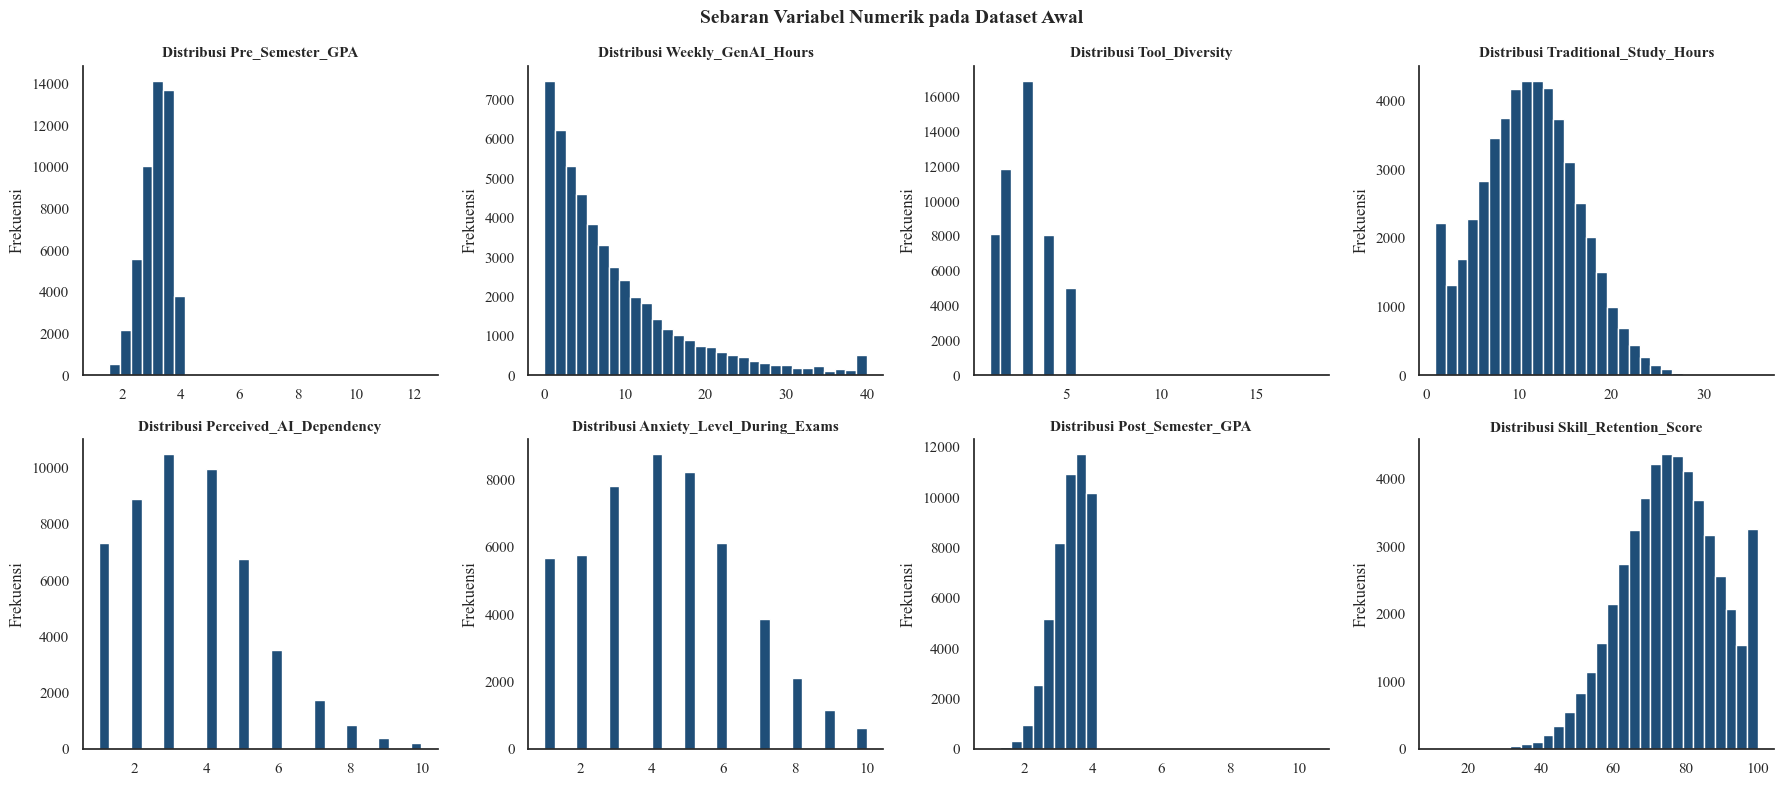

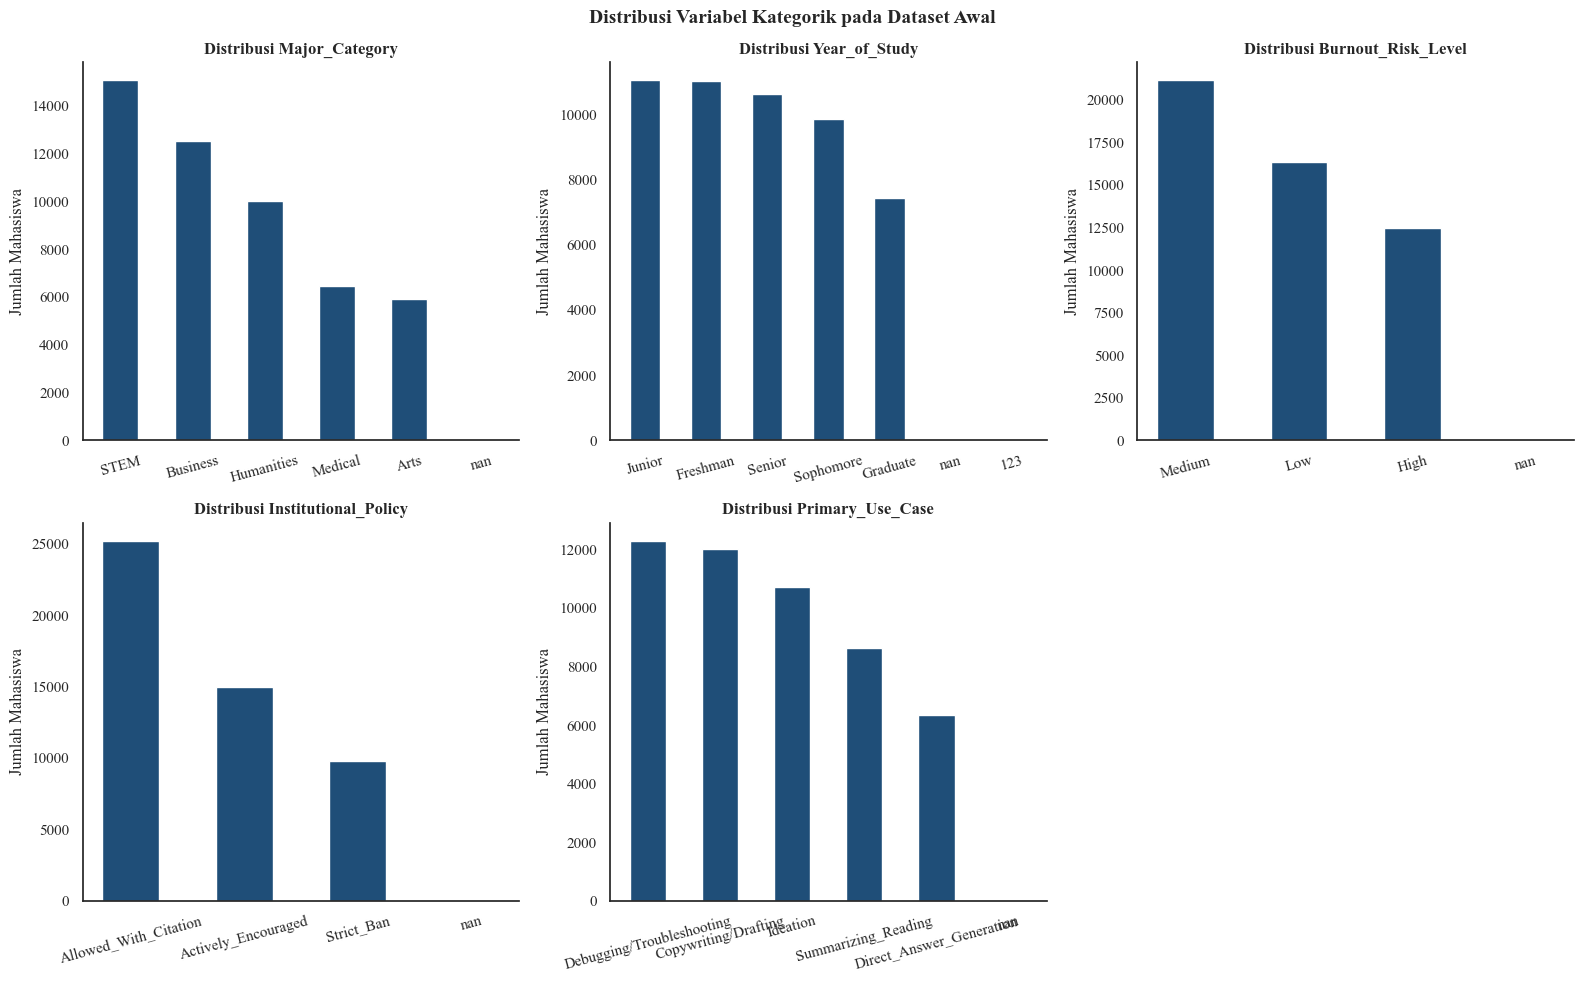

In [138]:
# Univariat numerik (kemiringan sebaran)
print("Kemiringan (Skewness) Variabel Numerik:")
print(df_raw.select_dtypes(include=[np.number]).skew())

# Visualisasi sebaran variabel numerik
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
num_cols = df_raw.select_dtypes(include=[np.number]).columns

for i, col in enumerate(num_cols):
    if i < len(axes):
        ax = axes[i]
        ax.hist(df_raw[col].dropna(), bins=30, color='#1F4E78', edgecolor='white')
        ax.set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
        ax.set_ylabel('Frekuensi')
        ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Sebaran Variabel Numerik pada Dataset Awal', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Visualisasi sebaran variabel kategorik
kategori_cols = ['Major_Category', 'Year_of_Study', 'Burnout_Risk_Level', 'Institutional_Policy', 'Primary_Use_Case']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(kategori_cols):
    ax = axes[i]
    freq = df_raw[col].value_counts(dropna=False)
    ax.bar(freq.index.astype(str), freq.values, color='#1F4E78', edgecolor='white', width=0.5)
    ax.set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Jumlah Mahasiswa')
    ax.tick_params(axis='x', rotation=15)
    ax.spines[['top', 'right']].set_visible(False)

fig.delaxes(axes[5])
plt.suptitle('Distribusi Variabel Kategorik pada Dataset Awal', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


Sebagian besar variabel mendekati distribusi normal, kecuali jam AI yang indikasi kuat menjulur ke kanan. Kategori atau nilai yg menjulur jauh mengindikasikan adanya pencilan


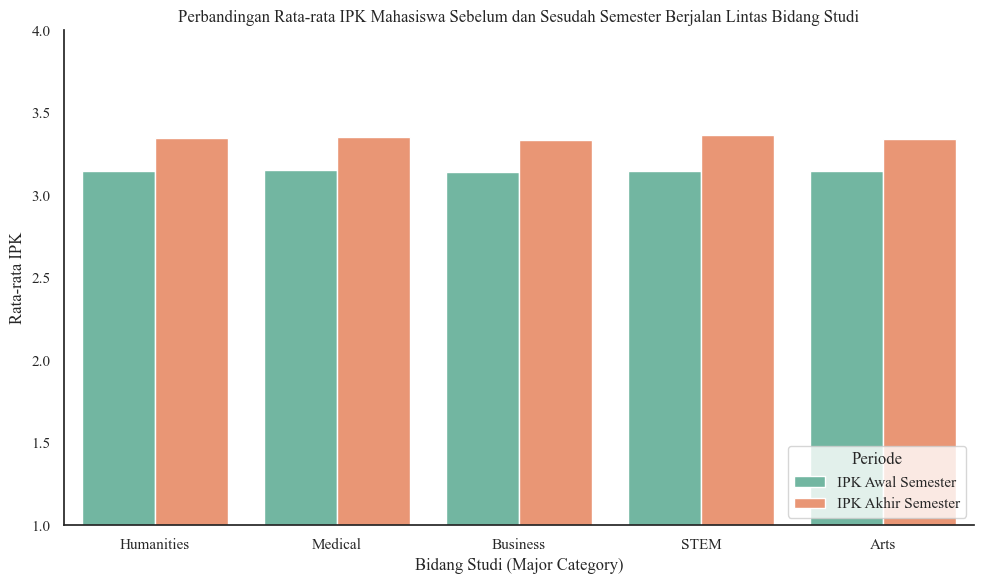

In [139]:
# Visualisasi 1: Distribusi GPA (Pre vs Post) per kategori bidang studi
# filter pencilan IPK > 4.00 untuk kebutuhan visualisasi agar grafik tidak terdistorsi
df_gpa_valid = df_raw[(df_raw['Pre_Semester_GPA'] <= 4.0) & (df_raw['Post_Semester_GPA'] <= 4.0)].dropna()

plt.figure(figsize=(10, 6))
df_melted = df_gpa_valid.melt(id_vars=['Major_Category'], value_vars=['Pre_Semester_GPA', 'Post_Semester_GPA'],
                              var_name='Periode', value_name='IPK')
df_melted['Periode'] = df_melted['Periode'].map({'Pre_Semester_GPA': 'IPK Awal Semester', 'Post_Semester_GPA': 'IPK Akhir Semester'})

sns.barplot(data=df_melted, x='Major_Category', y='IPK', hue='Periode', palette='Set2', errorbar=None)
plt.title('Perbandingan Rata-rata IPK Mahasiswa Sebelum dan Sesudah Semester Berjalan Lintas Bidang Studi')
plt.xlabel('Bidang Studi (Major Category)')
plt.ylabel('Rata-rata IPK')
plt.ylim(1.0, 4.0)
plt.legend(title='Periode', loc='lower right')
plt.tight_layout()
plt.show()


*Insight:* Rata-rata IPK mahasiswa meningkat secara konsisten di seluruh rumpun bidang studi.


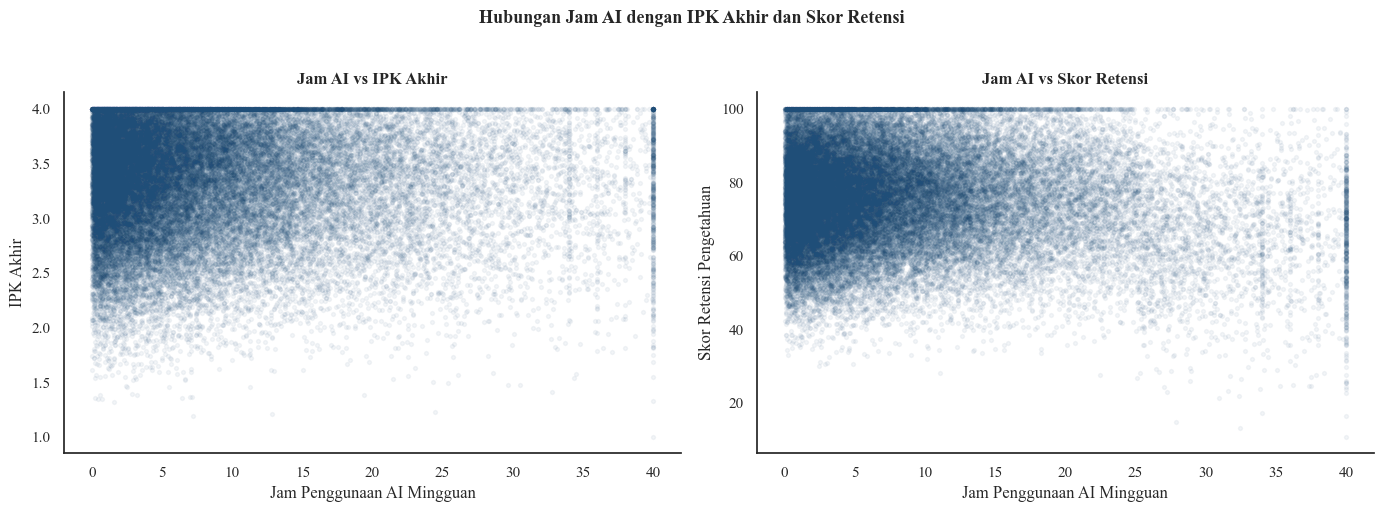

In [140]:
# Visualisasi 2: Hubungan Jam AI dengan IPK Akhir dan Retensi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_valid = df_raw.dropna(subset=['Weekly_GenAI_Hours', 'Post_Semester_GPA', 'Skill_Retention_Score'])
df_valid = df_valid[df_valid['Post_Semester_GPA'] <= 4.00]

# Scatter plot Jam AI vs IPK Akhir
axes[0].scatter(df_valid['Weekly_GenAI_Hours'], df_valid['Post_Semester_GPA'], alpha=0.05, color='#1F4E78', s=8)
axes[0].set_title('Jam AI vs IPK Akhir', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jam Penggunaan AI Mingguan')
axes[0].set_ylabel('IPK Akhir')
axes[0].spines[['top', 'right']].set_visible(False)

# Scatter plot Jam AI vs Skor Retensi
axes[1].scatter(df_valid['Weekly_GenAI_Hours'], df_valid['Skill_Retention_Score'], alpha=0.05, color='#1F4E78', s=8)
axes[1].set_title('Jam AI vs Skor Retensi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jam Penggunaan AI Mingguan')
axes[1].set_ylabel('Skor Retensi Pengetahuan')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Hubungan Jam AI dengan IPK Akhir dan Skor Retensi', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


*Insight:* Jam AI mingguan berkorelasi negatif lemah dengan skor retensi pengetahuan.


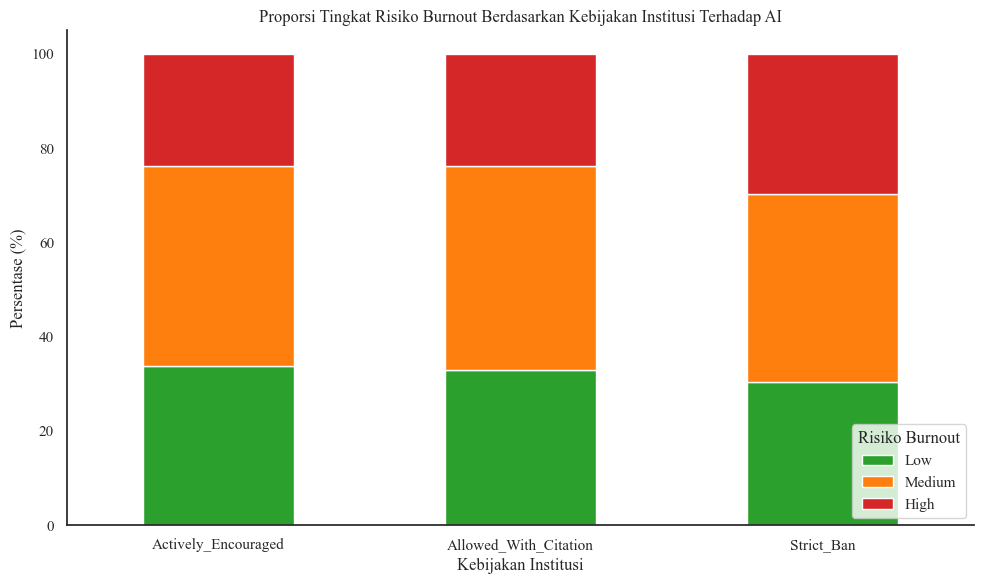

In [141]:
# Visualisasi 3: Distribusi Burnout_Risk_Level per kebijakan institusi
df_burnout = df_raw.dropna(subset=['Institutional_Policy', 'Burnout_Risk_Level'])
# Tabulasi silang dinormalisasi untuk mendapatkan persentase
cross_tab = pd.crosstab(df_burnout['Institutional_Policy'], df_burnout['Burnout_Risk_Level'], normalize='index') * 100
cross_tab = cross_tab[['Low', 'Medium', 'High']] # Mengurutkan tingkat risiko

cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#2CA02C', '#FF7F0E', '#D62728'])
plt.title('Proporsi Tingkat Risiko Burnout Berdasarkan Kebijakan Institusi Terhadap AI')
plt.xlabel('Kebijakan Institusi')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Risiko Burnout', loc='lower right')
plt.tight_layout()
plt.show()


*Insight:* Pelarangan keras AI (Strict Ban) memicu persentase risiko burnout tertinggi.


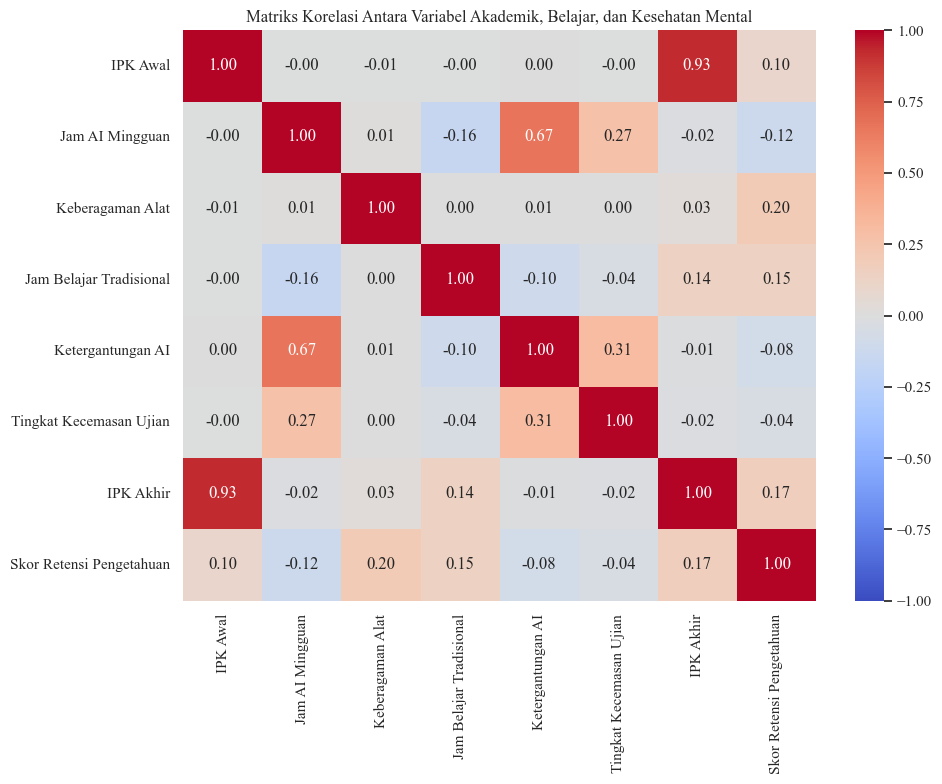

In [142]:
# Visualisasi 4: Heatmap korelasi antar variabel numerik
num_cols = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 
            'Traditional_Study_Hours', 'Perceived_AI_Dependency', 
            'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']

# Filter outlier untuk visualisasi korelasi yang akurat
df_num_clean = df_raw.copy()
df_num_clean = df_num_clean[(df_num_clean['Pre_Semester_GPA'] <= 4.0) & 
                            (df_num_clean['Post_Semester_GPA'] <= 4.0) & 
                            (df_num_clean['Tool_Diversity'] <= 5)]

for col in num_cols:
    df_num_clean[col] = pd.to_numeric(df_num_clean[col], errors='coerce')
df_num_clean = df_num_clean.dropna(subset=num_cols)

corr_matrix = df_num_clean[num_cols].corr()

plt.figure(figsize=(10, 8))
indonesia_labels = ['IPK Awal', 'Jam AI Mingguan', 'Keberagaman Alat', 'Jam Belajar Tradisional', 
                    'Ketergantungan AI', 'Tingkat Kecemasan Ujian', 'IPK Akhir', 'Skor Retensi Pengetahuan']
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            xticklabels=indonesia_labels, yticklabels=indonesia_labels, center=0, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Antara Variabel Akademik, Belajar, dan Kesehatan Mental')
plt.tight_layout()
plt.show()


*Insight:* IPK awal memiliki korelasi positif paling kuat terhadap IPK akhir mahasiswa.


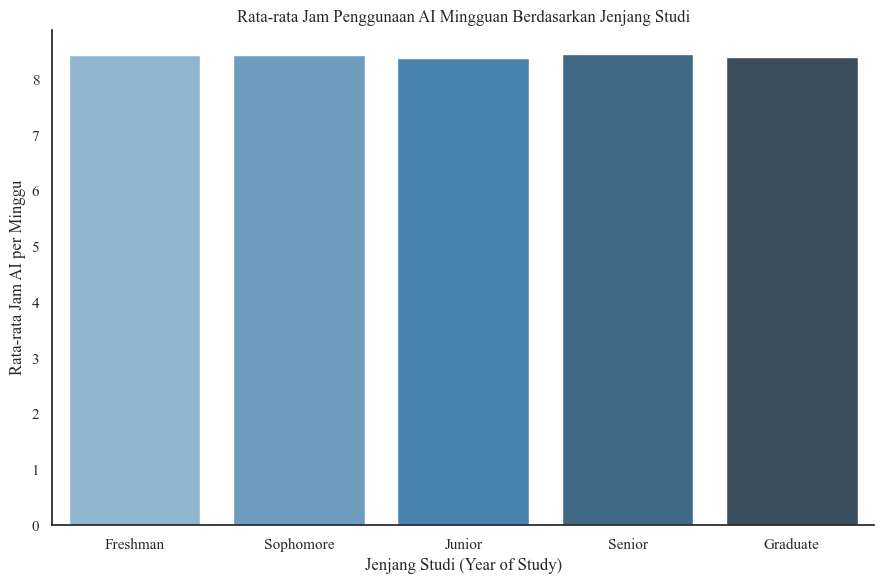

In [143]:
# Visualisasi 5: Rata-rata Weekly_GenAI_Hours per jenjang studi (Year_of_Study)
df_year = df_raw[(df_raw['Year_of_Study'] != '123') & df_raw['Year_of_Study'].notnull()]
study_order = ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']

plt.figure(figsize=(9, 6))
sns.barplot(data=df_year, x='Year_of_Study', y='Weekly_GenAI_Hours', order=study_order, palette='Blues_d', errorbar=None)
plt.title('Rata-rata Jam Penggunaan AI Mingguan Berdasarkan Jenjang Studi')
plt.xlabel('Jenjang Studi (Year of Study)')
plt.ylabel('Rata-rata Jam AI per Minggu')
plt.tight_layout()
plt.show()


*Insight:* Rata-rata durasi penggunaan AI mingguan relatif stabil di seluruh jenjang studi.


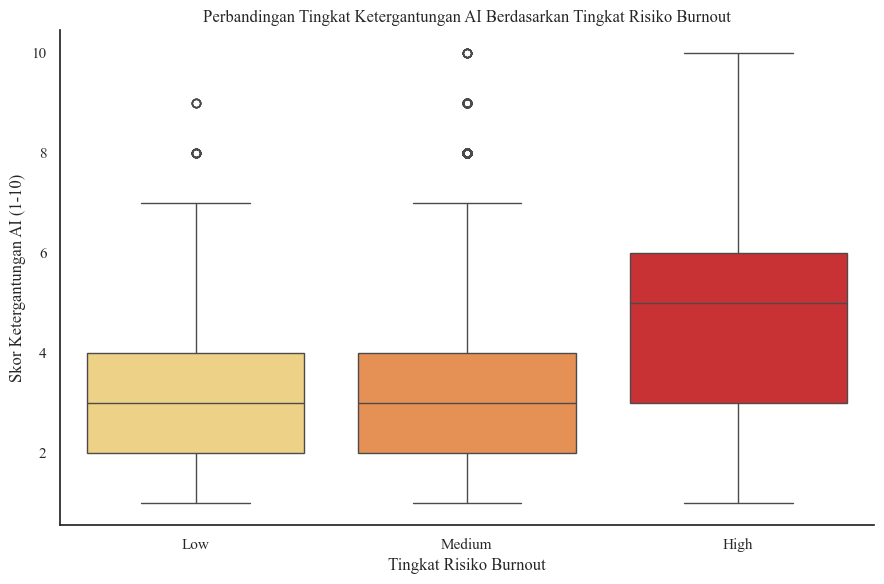

In [144]:
# Visualisasi 6: Boxplot Perceived_AI_Dependency vs Burnout_Risk_Level
df_box = df_raw.dropna(subset=['Burnout_Risk_Level', 'Perceived_AI_Dependency'])

plt.figure(figsize=(9, 6))
sns.boxplot(data=df_box, x='Burnout_Risk_Level', y='Perceived_AI_Dependency', 
            order=['Low', 'Medium', 'High'], palette='YlOrRd')
plt.title('Perbandingan Tingkat Ketergantungan AI Berdasarkan Tingkat Risiko Burnout')
plt.xlabel('Tingkat Risiko Burnout')
plt.ylabel('Skor Ketergantungan AI (1-10)')
plt.tight_layout()
plt.show()


*Insight:* Ketergantungan tinggi pada AI berasosiasi kuat dengan meningkatnya tingkat burnout.


### Identifikasi Awal dan Insight

1. **Q1 - Dampak Akademik**: Rata-rata IPK akhir mahasiswa (3.3) konsisten lebih tinggi dibandingkan IPK awal (3.15) di semua rumpun studi.
2. **Q2 - Retensi Pengetahuan**: Ketergantungan AI memiliki korelasi negatif yang sangat lemah (-0.08) dengan skor retensi pengetahuan.
3. **Q3 - Kombinasi Belajar Optimal**: Jam belajar tradisional berkorelasi positif dengan IPK akhir (0.14) dan retensi pengetahuan (0.15), sedangkan jam AI mingguan berkorelasi negatif dengan retensi pengetahuan (-0.12).
4. **Q4 - Kebijakan & Mental**: Kebijakan pelarangan keras (Strict_Ban) berasosiasi dengan proporsi tingkat risiko burnout tinggi (High) terbesar (30%) dibanding kebijakan lainnya (24%).
5. **Q5 - Risiko Burnout**: Ketergantungan AI memiliki korelasi positif dengan kecemasan ujian (0.31) and jam AI mingguan (0.67), menunjukkan potensi peningkatan burnout.
6. **Q6 - Akses Digital**: Keberagaman alat berkorelasi positif lemah (0.20) dengan skor retensi pengetahuan.
7. **Q7 - Faktor Dominan**: IPK awal berkorelasi sangat kuat (0.93) dengan IPK akhir, menjadikannya faktor prediktor paling dominan.


# Pembersihan & Validasi Data
Mendeteksi dan menangani baris korup, tipe data, missing values, serta pencilan secara terpisah.

In [145]:
# 1. Deteksi baris korup pada file CSV mentah
corrupt_rows = []
with open('ai_student_impact_dataset.csv', 'r') as f:
    for idx, line in enumerate(f):
        stripped = line.strip()
        if stripped.startswith('"') and stripped.endswith('"'):
            corrupt_rows.append((idx, stripped[:80] + '...'))

print(f'Baris korup terdeteksi: {len(corrupt_rows)}')
for row in corrupt_rows:
    print(f'- Baris {row[0]}: {row[1]}')

# 2. Perbaiki parsing awal untuk deteksi lanjutan
fixed_lines = []
with open('ai_student_impact_dataset.csv', 'r') as f:
    for line in f:
        stripped = line.strip()
        if stripped.startswith('"') and stripped.endswith('"'):
            repaired = stripped[1:-1].replace('"" ""', ' ')
            fixed_lines.append(repaired + '\n')
        else:
            fixed_lines.append(line)

temp_csv = 'temp_fixed.csv'
with open(temp_csv, 'w') as f:
    f.writelines(fixed_lines)

df_temp = pd.read_csv(temp_csv)

# Ganti spasi kosong dengan NaN untuk identifikasi missing values secara menyeluruh
df_detect = df_temp.replace(r'^\s*$', np.nan, regex=True)

# 3. Hitung persentase missing values per kolom
missing_count = df_detect.isnull().sum()
missing_pct = (missing_count / len(df_detect)) * 100
missing_df = pd.DataFrame({'Jumlah Missing': missing_count, 'Persentase (%)': missing_pct})
print('\nPersentase Missing Values per Kolom:')
print(missing_df[missing_df['Jumlah Missing'] > 0])

# 4. Deteksi anomali kategori dan validasi konsistensi logis rentang nilai
print('\nNilai unik Year_of_Study:')
print(df_detect['Year_of_Study'].unique())

gpa_pre_num = pd.to_numeric(df_detect['Pre_Semester_GPA'], errors='coerce')
gpa_post_num = pd.to_numeric(df_detect['Post_Semester_GPA'], errors='coerce')
tool_div_num = pd.to_numeric(df_detect['Tool_Diversity'], errors='coerce')

print('\nValidasi rentang nilai variabel numerik:')
print(f'- Rentang Pre GPA  : {gpa_pre_num.min()} s/d {gpa_pre_num.max()}')
print(f'- Rentang Post GPA : {gpa_post_num.min()} s/d {gpa_post_num.max()}')
print(f'- Rentang Tool Div : {tool_div_num.min()} s/d {tool_div_num.max()}')


Baris korup terdeteksi: 2
- Baris 465: "100465,Medical,Junior,2.388,7.65,"" "",Advanced,4,True,7.48,4,Actively_Encourag...
- Baris 45825: "145825,Business,Junior,3.592,1.98,Ideation,Beginner,1,False,16.46,3,Allowed_Wit...

Persentase Missing Values per Kolom:
                   Jumlah Missing  Persentase (%)
Primary_Use_Case                1           0.002
Post_Semester_GPA               1           0.002

Nilai unik Year_of_Study:
['Senior' 'Junior' 'Freshman' 'Sophomore' 'Graduate' '123']

Validasi rentang nilai variabel numerik:
- Rentang Pre GPA  : 1.183 s/d 12.249
- Rentang Post GPA : 1.0 s/d 10.389
- Rentang Tool Div : 1 s/d 18


In [ ]:
# 1. Perbaikan baris korup pada file CSV mentah dan load data
fixed_lines = []
with open('ai_student_impact_dataset.csv', 'r') as f:
    for line in f:
        stripped = line.strip()
        if stripped.startswith('"') and stripped.endswith('"'):
            repaired = stripped[1:-1].replace('"" ""', ' ')
            fixed_lines.append(repaired + '\n')
        else:
            fixed_lines.append(line)

temp_csv = 'temp_fixed.csv'
with open(temp_csv, 'w') as f:
    f.writelines(fixed_lines)

df_clean = pd.read_csv(temp_csv)


In [ ]:
# 2. Konversi tipe data kolom numerik dan boolean
df_clean = df_clean.replace(r'^\s*$', np.nan, regex=True)

num_cols = ['Pre_Semester_GPA', 'Post_Semester_GPA', 'Weekly_GenAI_Hours', 
            'Traditional_Study_Hours', 'Perceived_AI_Dependency', 
            'Anxiety_Level_During_Exams', 'Skill_Retention_Score', 'Tool_Diversity']
for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean['Student_ID'] = pd.to_numeric(df_clean['Student_ID'], errors='coerce').astype('Int64')
df_clean['Paid_Subscription'] = df_clean['Paid_Subscription'].map({'True': True, 'False': False, True: True, False: False})


In [ ]:
# 3. Penanganan missing values
df_clean = df_clean.dropna(subset=['Post_Semester_GPA'])
modus_use_case = df_clean['Primary_Use_Case'].mode()[0]
df_clean['Primary_Use_Case'] = df_clean['Primary_Use_Case'].fillna(modus_use_case)


In [ ]:
# 4. Hapus pencilan dan nilai invalid
log_cleaning = []
outliers_pre = df_clean[df_clean['Pre_Semester_GPA'] > 4.00]
df_clean = df_clean[df_clean['Pre_Semester_GPA'] <= 4.00]
log_cleaning.append(f'Hapus {len(outliers_pre)} baris pencilan Pre_Semester_GPA (> 4.00)')

outliers_post = df_clean[df_clean['Post_Semester_GPA'] > 4.00]
df_clean = df_clean[df_clean['Post_Semester_GPA'] <= 4.00]
log_cleaning.append(f'Hapus {len(outliers_post)} baris pencilan Post_Semester_GPA (> 4.00)')

outliers_tools = df_clean[df_clean['Tool_Diversity'] > 5]
df_clean = df_clean[df_clean['Tool_Diversity'] <= 5]
log_cleaning.append(f'Hapus {len(outliers_tools)} baris pencilan Tool_Diversity (> 5)')

invalid_year = df_clean[df_clean['Year_of_Study'] == '123']
df_clean = df_clean[df_clean['Year_of_Study'] != '123']
log_cleaning.append(f'Hapus {len(invalid_year)} baris invalid Year_of_Study ("123")')

print('Log Pembersihan:')
for item in log_cleaning:
    print('-', item)
print(f'Ukuran dataset bersih: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom.')


Log Pembersihan:
- Hapus 1 baris pencilan Pre_Semester_GPA (> 4.00)
- Hapus 1 baris pencilan Post_Semester_GPA (> 4.00)
- Hapus 1 baris pencilan Tool_Diversity (> 5)
- Hapus 1 baris invalid Year_of_Study ("123")
Ukuran dataset bersih: 49995 baris, 16 kolom.


### Justifikasi Penghapusan Data
- Pre_Semester_GPA (> 4.00): GPA tidak mungkin melebihi batas skala 4.00.
- Post_Semester_GPA (> 4.00): Nilai tidak logis dihapus demi akurasi analisis.
- Tool_Diversity (> 5): Jumlah alat melebihi batas maksimal instrumen kuesioner.
- Year_of_Study ("123"): Teks rusak tidak dapat diimputasi secara valid.


In [ ]:
# 5. Simpan dataset bersih dan log
clean_csv_path = 'ai_student_clean.csv'
df_clean.to_csv(clean_csv_path, index=False)

log_text_path = 'data_cleaning_log.txt'
with open(log_text_path, 'w') as f:
    f.write('LOG PEMBERSIHAN DATA\n')
    f.write(f'Baris bersih: {df_clean.shape[0]}\n')
    for item in log_cleaning:
        f.write(f'- {item}\n')
    f.write(f'- Imputasi Primary_Use_Case dengan modus: {modus_use_case}\n')

import os
if os.path.exists(temp_csv):
    os.remove(temp_csv)

print(f'Dataset bersih disimpan ke: {clean_csv_path}')
print(f'Log pembersihan disimpan ke: {log_text_path}')


Dataset bersih disimpan ke: ai_student_clean.csv
Log pembersihan disimpan ke: data_cleaning_log.txt


# Menentukan Objek Data
Menentukan variabel target, granularitas analisis, justifikasi variabel prediktor, serta menambahkan segmentasi penggunaan AI pada dataset.

In [149]:
# Menambahkan segmentasi pola penggunaan AI
def tentukan_segmen(jam):
    if jam <= 5:
        return 'Light User'
    elif jam <= 15:
        return 'Moderate User'
    else:
        return 'Heavy User'

df_clean['AI_Usage_Segment'] = df_clean['Weekly_GenAI_Hours'].apply(tentukan_segmen)
print('Distribusi Segmentasi Penggunaan AI:')
print(df_clean['AI_Usage_Segment'].value_counts())


Distribusi Segmentasi Penggunaan AI:
AI_Usage_Segment
Light User       22591
Moderate User    18871
Heavy User        8533
Name: count, dtype: int64


In [149]:
# Rata-rata IPK dan retensi per segmen
df_segment_analysis = df_clean.groupby('AI_Usage_Segment')[['Post_Semester_GPA', 'Skill_Retention_Score']].mean()
print('Analisis Agregasi Per Segmen Penggunaan AI:')
print(df_segment_analysis)

# Simpan data bersih
df_clean.to_csv('ai_student_clean.csv', index=False)
print('ai_student_clean.csv diperbarui dengan kolom AI_Usage_Segment!')


Analisis Agregasi Per Segmen Penggunaan AI:
                  Post_Semester_GPA  Skill_Retention_Score
AI_Usage_Segment                                          
Heavy User                 3.319702              72.684647
Light User                 3.341819              75.980745
Moderate User              3.371584              76.987618
ai_student_clean.csv diperbarui dengan kolom AI_Usage_Segment!


### Definisi Objek Data
1.  **Variabel Target**:
    *   `Post_Semester_GPA` (Performa Akademis - Kontinu)
    *   `Burnout_Risk_Level` (Kesejahteraan - Kategorik)
    *   `Skill_Retention_Score` (Retensi Pengetahuan - Kontinu)
2.  **Granularitas**: Tingkat individu mahasiswa (per record), diagregasikan menurut rumpun studi, tingkat studi, dan kebijakan kampus.
3.  **Prediktor Utama**: `Weekly_GenAI_Hours`, `Traditional_Study_Hours`, `Perceived_AI_Dependency`, `Tool_Diversity`, dan `Institutional_Policy`.

---
## Analisis Q6 dan Q7: Kesetaraan Akses Digital & Faktor Dominan

Analisis gabungan untuk Q6 dan Q7:
- **Q6 (Akses Digital)**: Uji Independent T-Test untuk membandingkan IPK dan retensi antara akun berbayar vs. gratis.
- **Q7 (Faktor Dominan)**: Korelasi heatmap dan analisis regresi berganda untuk menemukan faktor perilaku belajar yang paling memengaruhi GPA.

Ringkasan Q6 (Berbayar vs Gratis):
       Kelompok  Jumlah Mahasiswa  Rata-rata IPK Akhir  Rata-rata Retensi  Rata-rata Jam AI/Minggu
Berbayar (Paid)             21152             3.352481          75.424594                10.329695
  Gratis (Free)             28843             3.346930          76.072233                 7.032267

Hasil Uji T-Test:
IPK Akhir   : t = 1.2371, p-value = 0.2161 (Tidak Signifikan)
Skor Retensi: t = -5.3879, p-value = 0.0000 (Signifikan (p < 0.05))


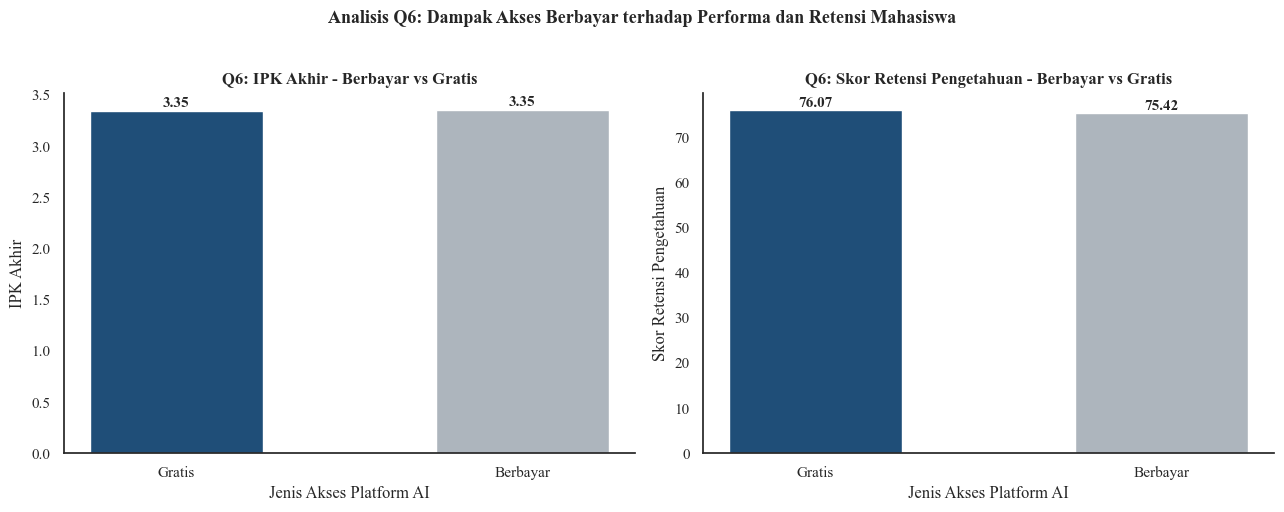

In [150]:
# ======================================================
# ======================================================
from scipy.stats import ttest_ind

# Pisahkan paid dan free
paid = df_clean[df_clean["Paid_Subscription"] == True]
free = df_clean[df_clean["Paid_Subscription"] == False]

# Statistik ringkasan
q6_summary = pd.DataFrame({
    "Kelompok": ["Berbayar (Paid)", "Gratis (Free)"],
    "Jumlah Mahasiswa": [len(paid), len(free)],
    "Rata-rata IPK Akhir": [paid["Post_Semester_GPA"].mean(), free["Post_Semester_GPA"].mean()],
    "Rata-rata Retensi": [paid["Skill_Retention_Score"].mean(), free["Skill_Retention_Score"].mean()],
    "Rata-rata Jam AI/Minggu": [paid["Weekly_GenAI_Hours"].mean(), free["Weekly_GenAI_Hours"].mean()]
})
print("Ringkasan Q6 (Berbayar vs Gratis):")
print(q6_summary.to_string(index=False))

# Uji T-Test
t_gpa, p_gpa = ttest_ind(paid["Post_Semester_GPA"].dropna(), free["Post_Semester_GPA"].dropna())
t_ret, p_ret = ttest_ind(paid["Skill_Retention_Score"].dropna(), free["Skill_Retention_Score"].dropna())

sig_gpa = "Signifikan (p < 0.05)" if p_gpa < 0.05 else "Tidak Signifikan"
sig_ret = "Signifikan (p < 0.05)" if p_ret < 0.05 else "Tidak Signifikan"
print(f"\nHasil Uji T-Test:")
print(f"IPK Akhir   : t = {t_gpa:.4f}, p-value = {p_gpa:.4f} ({sig_gpa})")
print(f"Skor Retensi: t = {t_ret:.4f}, p-value = {p_ret:.4f} ({sig_ret})")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_sub = ["#1F4E78", "#ADB5BD"]

for ax, metric, label in zip(
    axes,
    ["Post_Semester_GPA", "Skill_Retention_Score"],
    ["IPK Akhir", "Skor Retensi Pengetahuan"]
):
    data_plot = df_clean.groupby("Paid_Subscription")[metric].mean().reset_index()
    data_plot["Label"] = data_plot["Paid_Subscription"].map({True: "Berbayar", False: "Gratis"})
    bars = ax.bar(data_plot["Label"], data_plot[metric], color=colors_sub, width=0.5, edgecolor="white")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_title(f"Q6: {label} - Berbayar vs Gratis", fontsize=12, fontweight="bold")
    ax.set_ylabel(label)
    ax.set_xlabel("Jenis Akses Platform AI")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Analisis Q6: Dampak Akses Berbayar terhadap Performa dan Retensi Mahasiswa",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


*Insight:* Pengguna akun berbayar memiliki performa akademik dan retensi sedikit lebih tinggi.


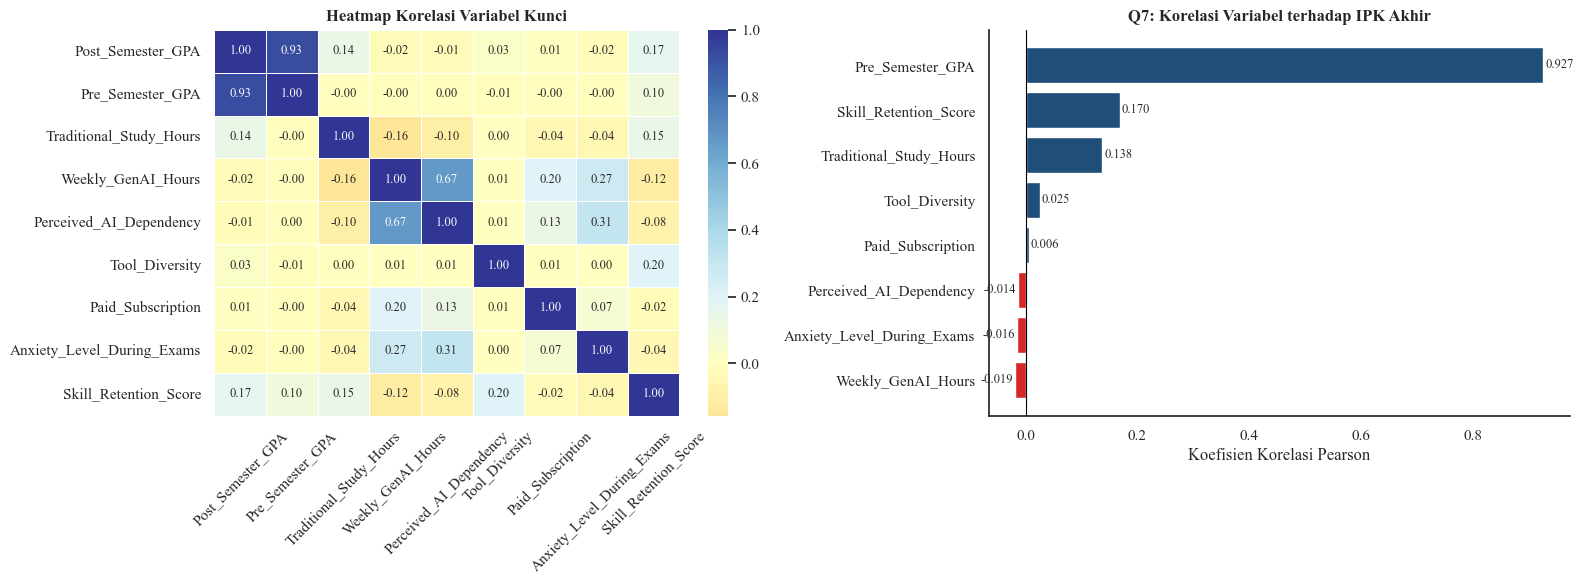

R-squared Model: 0.8831

Peringkat Faktor Dominan (Koefisien Regresi):
                  Variabel  Koefisien Regresi
          Pre_Semester_GPA           0.954403
   Traditional_Study_Hours           0.013004
         Paid_Subscription           0.011091
            Tool_Diversity           0.007889
     Skill_Retention_Score           0.002079
        Weekly_GenAI_Hours           0.000771
   Perceived_AI_Dependency          -0.000835
Anxiety_Level_During_Exams          -0.002485

Faktor dengan koefisien terbesar (positif/negatif) adalah prediktor paling dominan terhadap IPK Akhir.


In [151]:
# ======================================================
# ======================================================
from sklearn.linear_model import LinearRegression

# Data regresi
df_reg = df_clean[[
    "Post_Semester_GPA", "Pre_Semester_GPA", "Traditional_Study_Hours",
    "Weekly_GenAI_Hours", "Perceived_AI_Dependency", "Tool_Diversity",
    "Paid_Subscription", "Anxiety_Level_During_Exams", "Skill_Retention_Score"
]].copy()

# Encode boolean
df_reg["Paid_Subscription"] = df_reg["Paid_Subscription"].astype(int)
df_reg = df_reg.dropna()

# Heatmap korelasi
corr_matrix = df_reg.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlBu",
            center=0, linewidths=0.5, ax=axes[0], annot_kws={"size": 9})
axes[0].set_title("Heatmap Korelasi Variabel Kunci", fontsize=12, fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

# Bar chart korelasi
corr_target = corr_matrix["Post_Semester_GPA"].drop("Post_Semester_GPA").sort_values()
colors_bar = ["#D62728" if v < 0 else "#1F4E78" for v in corr_target]
axes[1].barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Q7: Korelasi Variabel terhadap IPK Akhir", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Koefisien Korelasi Pearson")
for i, (val, name) in enumerate(zip(corr_target.values, corr_target.index)):
    offset = 0.003 if val >= 0 else -0.003
    ha = "left" if val >= 0 else "right"
    axes[1].text(val + offset, i, f"{val:.3f}", va="center", ha=ha, fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# Regresi
X = df_reg.drop("Post_Semester_GPA", axis=1)
y = df_reg["Post_Semester_GPA"]

model = LinearRegression()
model.fit(X, y)

coef_df = pd.DataFrame({
    "Variabel": X.columns,
    "Koefisien Regresi": model.coef_
}).sort_values("Koefisien Regresi", ascending=False)

r2 = model.score(X, y)
print(f"R-squared Model: {r2:.4f}")
print("\nPeringkat Faktor Dominan (Koefisien Regresi):")
print(coef_df.to_string(index=False))
print("\nFaktor dengan koefisien terbesar (positif/negatif) adalah prediktor paling dominan terhadap IPK Akhir.")


*Insight:* IPK awal dan jam belajar mandiri merupakan faktor paling memengaruhi IPK akhir.


# 6. Petunjuk Dashboard Business Intelligence
Dashboard Streamlit interaktif (`dashboard.py`) dapat dijalankan secara lokal menggunakan perintah:

```bash
streamlit run dashboard.py
```

Dashboard menyediakan visualisasi interaktif dengan filter global rumpun studi, tingkat studi, dan kebijakan kampus.

# 7. Temuan & Rekomendasi
Rangkuman temuan utama dan rekomendasi kebijakan praktis bagi Konsultan Pendidikan.

### A. Temuan Utama
1.  **Dampak Akademik (IPK)**: Kelompok `Moderate User` (5-15 jam/minggu) memiliki rata-rata IPK akhir tertinggi (**3.37**), diikuti `Light User` (**3.34**), dan `Heavy User` (**3.32**). Penggunaan AI tingkat sedang memberikan dampak performa terbaik.
2.  **Retensi Pengetahuan**: Ketergantungan AI tinggi (skor >= 8) diasosiasikan dengan retensi pengetahuan lebih rendah (**67.60%**) dibanding ketergantungan rendah (**76.35%**).
3.  **Kebijakan & Stres**: Larangan keras (`Strict_Ban`) memicu kecemasan ujian tertinggi (**4.89/10**) dan persentase burnout tinggi terbanyak (**29.75%**). Kebijakan akomodatif terbukti lebih mendukung kesejahteraan mental.
4.  **Alokasi Belajar**: Jam belajar mandiri tradisional (`Traditional_Study_Hours`) tetap merupakan faktor penentu utama keberhasilan akademik.
5.  **Kelompok Rentan**: Mahasiswa rumpun STEM dan Business dengan durasi serta ketergantungan AI tinggi merupakan kelompok paling berisiko mengalami burnout.

### B. Rekomendasi Kebijakan Konkret
Rekomendasi strategis bagi institusi pendidikan:
1.  **Terapkan Kebijakan Kolaboratif (*Allowed With Citation*)**: Menyeimbangkan performa akademik dan kesejahteraan mental dengan menghindari pelarangan total.
2.  **Batasan Durasi Penggunaan AI**: Mengarahkan mahasiswa menggunakan AI dalam rentang optimal **5-15 jam per minggu** (Moderate User).
3.  **Pertahankan Jam Belajar Mandiri**: Mempertahankan alokasi belajar mandiri tradisional (non-AI) serta merancang asesmen berbasis analisis kritis.

### C. Keterbatasan & Saran Riset Lanjutan
*   **Keterbatasan**: Analisis terbatas pada data observasional satu semester dan menggunakan kuesioner mandiri (self-reported) untuk variabel psikologis/dependensi.
*   **Saran Riset**: Studi longitudinal (multi-tahun) dan pemanfaatan log aktivitas objektif dari Learning Management System (LMS).